# Modeling 
1. Import libraries 
2. Load and split data (train and test)
3. Process data (train and test)
4. Fit model (train): .fit()
5. Model evaluation: CV RMSE, Train RMSE, MAE, Train R squared, Residuals, ...
6. Predict (test): .predict

## Import packages and pipeline

In [35]:
# import function built in pipeline
import sys
sys.path.append("../scripts")

import numpy as np
import pandas as pd

from preprocess import Pipeline, preprocess_data
from load_data import load_data, split_xy

# for modeling
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict
import xgboost as xgb


# for visualization
import matplotlib.pyplot as plt

## Load & process Data

In [2]:
# Load train data and split
train_df = load_data("../data/train.csv")
train_X, train_y = split_xy(train_df)

In [3]:
# Load test data and split
test_df = load_data("../data/test.csv")
test_X = test_df.copy()

In [4]:
# Process data and check
train_X_processed, test_X_processed, pipeline = preprocess_data(train_X, test_X)

# Pipeline phải được fit 1 lần duy nhất trên train data, sau đó dùng cùng pipeline đó để transform test data
# Không gọi thành 2 lần khác nhau XXXX

## Fit model

## Simple Linear Regression

In [5]:
# fit model
model = LinearRegression()
model.fit(train_X_processed, train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### MRSE, MAE, R-squared

In [6]:
# Cross validation within test set
scores = cross_val_score(
    model, 
    train_X_processed, 
    train_y, 
    scoring="neg_root_mean_squared_error", cv=5)
print("RMSE CV:", -scores.mean())

RMSE CV: 35544.32279123108


In [7]:
# Predict with test set
train_y_pred = model.predict(train_X_processed)

In [8]:
# metrics
train_rmse = np.sqrt(mean_squared_error(train_y, train_y_pred))
train_mae = mean_absolute_error(train_y, train_y_pred)
train_r2 = r2_score(train_y, train_y_pred)

print(f"Train RMSE: {train_rmse}")
print(f"Train MAE: {train_mae}")
print(f"Train R²: {train_r2}")

Train RMSE: 22586.2217827366
Train MAE: 15173.728831216162
Train R²: 0.9191129673184198


*Refer to: https://medium.com/@jaberi.mohamedhabib/evaluating-model-performance-training-vs-cross-validation-rmse-ce0717dc70fb*

**RMSE CV: 35,544 vs Train RMSE: 22,586**
- RMSE CV (Cross-Validation): Sai số trung bình khi model dự đoán trên data chưa thấy
- Train RMSE: Sai số trung bình khi model dự đoán trên data đã học

--> RMSE CV cao hơn nhiều so với Train RMSE (35,544 vs 22,586) 

--> OVERFITTING

**Train MAE: 15,174**
- Mean Absolute Error: Trung bình sai lệch tuyệt đối
- Model sai trung bình ~$15,174 khi dự đoán giá nhà

**Train R²: 0.919**
- R² = 91.9% → Model giải thích được 91.9% variance trong data
- Càng gần 1 càng tốt (max = 1)

--> Nhưng kết hợp với CV RMSE cao

--> OVERFITTING

### Residuals

In [9]:
# residuals
residuals = train_y - train_y_pred

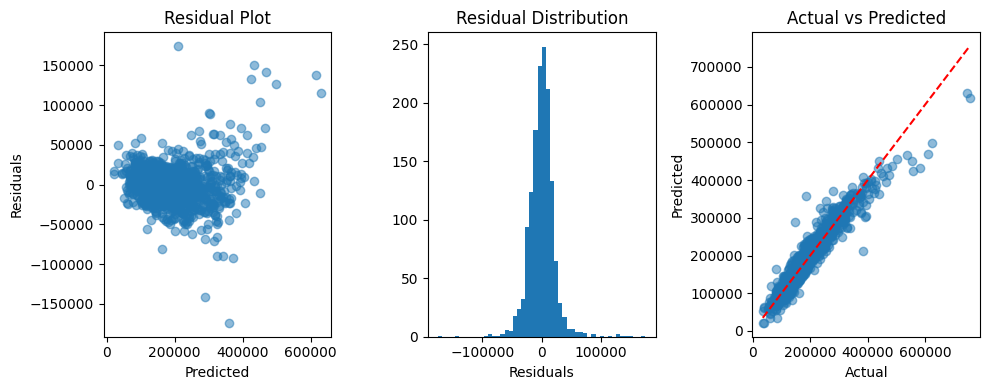

In [10]:
# Create a 1x3 grid of plots
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

# 1. Residual Plot
ax[0].scatter(train_y_pred, residuals, alpha=0.5)
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Residuals')
ax[0].set_title('Residual Plot')

# 2. Distribution of residuals
ax[1].hist(residuals, bins=50)
ax[1].set_xlabel('Residuals')
ax[1].set_title('Residual Distribution')

# 3. Actual vc Predict y
ax[2].scatter(train_y, train_y_pred, alpha=0.5)
ax[2].plot([train_y.min(), train_y.max()], [train_y.min(), train_y.max()], 'r--')
ax[2].set_xlabel('Actual')
ax[2].set_ylabel('Predicted')
ax[2].set_title('Actual vs Predicted')

# Adjust layout for spacing
plt.tight_layout()
plt.show()

**Residual Plot**
- Trục X: Giá dự đoán
- Trục Y: Sai số (Actual - Predicted)

--> Residuals phân bố khá đều quanh y=0, hông có pattern rõ ràng, có outliers

**Residual Distribution**
- Phân phối gần như chuẩn (bell-shaped)
- Tập trung quanh 0

**Actual vs Predicted**
- Trục X: Giá thật
- Trục Y: Giá dự đoán
- Đường đỏ chéo: dự đoán đúng (actual = predicted)

--> Hầu hết điểm nằm gần đường đỏ

## ELastic Net Regression

**Mô hình hiện tại OVERFITTING --> Đổi sang dùng Elastic Net Regression để làm tiếp**

*Refer to: https://phamdinhkhanh.github.io/deepai-book/ch_ml/index_RidgedRegression.html*

In [11]:
# Fit model with Elastic Net Regression instead of Simple Linear Regression
model = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
model.fit(train_X_processed, train_y)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.798e+11, tolerance: 9.208e+08
  model = cd_fast.enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [12]:
# Cross validation within test set
scores = cross_val_score(
    model, 
    train_X_processed, 
    train_y, 
    scoring="neg_root_mean_squared_error", cv=5)
print("RMSE CV:", -scores.mean())

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.854e+11, tolerance: 7.592e+08
  model = cd_fast.enet_coordinate_descent(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.194e+11, tolerance: 7.288e+08
  model = cd_fast.enet_coordinate_descent(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation.

RMSE CV: 32744.298354971186


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.250e+11, tolerance: 7.249e+08
  model = cd_fast.enet_coordinate_descent(


In [13]:
# Predict with test set
train_y_pred = model.predict(train_X_processed)

In [14]:
# metrics
train_rmse = np.sqrt(mean_squared_error(train_y, train_y_pred))
train_mae = mean_absolute_error(train_y, train_y_pred)
train_r2 = r2_score(train_y, train_y_pred)

print(f"Train RMSE: {train_rmse}")
print(f"Train MAE: {train_mae}")
print(f"Train R²: {train_r2}")

Train RMSE: 29188.48836822002
Train MAE: 17199.91986742612
Train R²: 0.8649125713202372


In [15]:
# residuals
residuals = train_y - train_y_pred

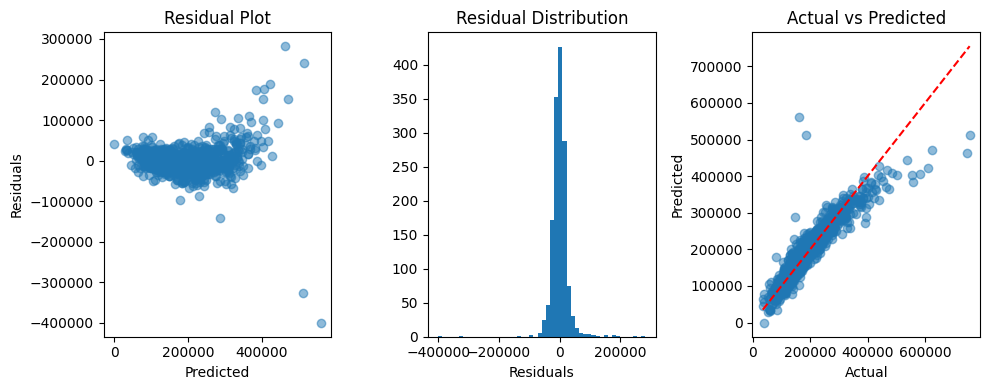

In [16]:
# Create a 1x3 grid of plots
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

# 1. Residual Plot
ax[0].scatter(train_y_pred, residuals, alpha=0.5)
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Residuals')
ax[0].set_title('Residual Plot')

# 2. Distribution of residuals
ax[1].hist(residuals, bins=50)
ax[1].set_xlabel('Residuals')
ax[1].set_title('Residual Distribution')

# 3. Actual vc Predict y
ax[2].scatter(train_y, train_y_pred, alpha=0.5)
ax[2].plot([train_y.min(), train_y.max()], [train_y.min(), train_y.max()], 'r--')
ax[2].set_xlabel('Actual')
ax[2].set_ylabel('Predicted')
ax[2].set_title('Actual vs Predicted')

# Adjust layout for spacing
plt.tight_layout()
plt.show()

In [17]:
# tune model
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

grid = GridSearchCV(
    ElasticNet(random_state=42),
    param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

grid.fit(train_X_processed, train_y)

grid.best_params_, -grid.best_score_

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.547e+11, tolerance: 7.288e+08
  model = cd_fast.enet_coordinate_descent(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.059e+11, tolerance: 7.592e+08
  model = cd_fast.enet_coordinate_descent(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation.

({'alpha': 0.01, 'l1_ratio': 0.1}, np.float64(32349.89815748152))

In [18]:
# ({'alpha': 0.01, 'l1_ratio': 0.1}, np.float64(32349.89815748152))

In [19]:
# Fit model with Elastic Net Regression instead of Simple Linear Regression WITH TUNED PARAMETER

model = ElasticNet(alpha=0.01, l1_ratio=0.1, random_state=42)
elastic_model = model.fit(train_X_processed, train_y)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.870e+11, tolerance: 9.208e+08
  model = cd_fast.enet_coordinate_descent(


In [20]:
# Cross validation within test set
scores = cross_val_score(
    model, 
    train_X_processed, 
    train_y, 
    scoring="neg_root_mean_squared_error", cv=5)
print("RMSE CV:", -scores.mean())

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.050e+11, tolerance: 7.592e+08
  model = cd_fast.enet_coordinate_descent(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.404e+11, tolerance: 7.288e+08
  model = cd_fast.enet_coordinate_descent(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation.

RMSE CV: 32349.89815748152


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.612e+11, tolerance: 7.249e+08
  model = cd_fast.enet_coordinate_descent(


In [21]:
# Predict with test set
train_y_pred = model.predict(train_X_processed)

In [22]:
# metrics
train_rmse = np.sqrt(mean_squared_error(train_y, train_y_pred))
train_mae = mean_absolute_error(train_y, train_y_pred)
train_r2 = r2_score(train_y, train_y_pred)

print(f"Train RMSE: {train_rmse}")
print(f"Train MAE: {train_mae}")
print(f"Train R²: {train_r2}")

Train RMSE: 27103.89058464021
Train MAE: 16672.76187360043
Train R²: 0.8835190247964431


In [23]:
# residuals
residuals = train_y - train_y_pred

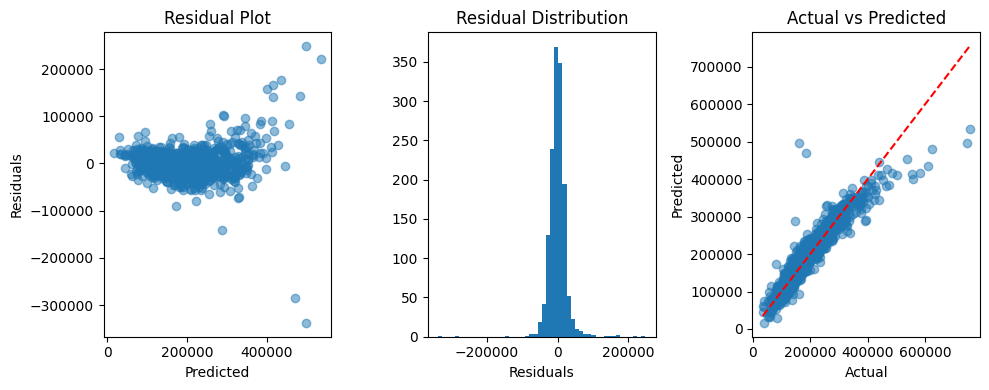

In [24]:
# Create a 1x3 grid of plots
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

# 1. Residual Plot
ax[0].scatter(train_y_pred, residuals, alpha=0.5)
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Residuals')
ax[0].set_title('Residual Plot')

# 2. Distribution of residuals
ax[1].hist(residuals, bins=50)
ax[1].set_xlabel('Residuals')
ax[1].set_title('Residual Distribution')

# 3. Actual vc Predict y
ax[2].scatter(train_y, train_y_pred, alpha=0.5)
ax[2].plot([train_y.min(), train_y.max()], [train_y.min(), train_y.max()], 'r--')
ax[2].set_xlabel('Actual')
ax[2].set_ylabel('Predicted')
ax[2].set_title('Actual vs Predicted')

# Adjust layout for spacing
plt.tight_layout()
plt.show()

## Gradient Boosting

*Refer to: https://viblo.asia/p/gradient-boosting-tat-tan-tat-ve-thuat-toan-manh-me-nhat-trong-machine-learning-YWOZrN7vZQ0*

In [26]:
# log transform y
y_train_log = np.log1p(train_y)

In [27]:
# initialize XGBClassifier with the evaluation metric specified as a model parameter
xgb_model = xgb.XGBRegressor(
    n_estimators=500,       
    learning_rate=0.05,     
    max_depth=3,            
    min_child_weight=1,
    subsample=0.8,          
    colsample_bytree=0.8,   
    reg_alpha=0.005,        
    reg_lambda=0.005,       
    random_state=42,
    n_jobs=-1
)

In [28]:
# train the model
xgb_model.fit(train_X_processed, np.log1p(train_y))

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [29]:
def evaluate_model(model, X_train, y_train, model_name="Model", use_log=False, skip_cv=False):
    
    scores = None
    cv_rmse = None
    
    # 1. Cross validation
    if not skip_cv:
        try:
            y_for_cv = np.log1p(y_train) if use_log else y_train
            
            if use_log:
                y_pred_cv = cross_val_predict(model, X_train, y_for_cv, cv=5)
                y_pred_cv_original = np.expm1(y_pred_cv)
                cv_rmse = np.sqrt(mean_squared_error(y_train, y_pred_cv_original))
                print(f"CV-RMSE: ${cv_rmse:,.2f}")
            else:
                scores = cross_val_score(
                    model, 
                    X_train, 
                    y_for_cv, 
                    scoring="neg_root_mean_squared_error", 
                    cv=5
                )
                print(f"CV-RMSE: ${-scores.mean():,.2f} (+/- ${scores.std():,.2f})")
        except Exception as e:
            print(f"CV skipped (error: {str(e)[:50]}...)")
    
    # 2. Predict
    y_pred = model.predict(X_train)
    if use_log:
        y_pred = np.expm1(y_pred)
    
    # 3. Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred))
    train_mae = mean_absolute_error(y_train, y_pred)
    train_r2 = r2_score(y_train, y_pred)
    print(f"Train RMSE: ${train_rmse:,.2f}")
    print(f"Train MAE: ${train_mae:,.2f}")
    print(f"Train R²: {train_r2:.4f}\n")
    
    # 4. Residuals
    residuals = y_train - y_pred
    
    # 5. Plots
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'{model_name} Evaluation', fontsize=14)
    
    ax[0].scatter(y_pred, residuals, alpha=0.5)
    ax[0].axhline(y=0, color='r', linestyle='--')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Residuals')
    ax[0].set_title('Residual Plot')
    
    ax[1].hist(residuals, bins=50)
    ax[1].set_xlabel('Residuals')
    ax[1].set_title('Residual Distribution')
    
    ax[2].scatter(y_train, y_pred, alpha=0.5)
    ax[2].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
    ax[2].set_xlabel('Actual')
    ax[2].set_ylabel('Predicted')
    ax[2].set_title('Actual vs Predicted')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'cv_rmse': cv_rmse if cv_rmse is not None else (-scores.mean() if scores is not None else None),
        'train_rmse': train_rmse,
        'train_mae': train_mae,
        'train_r2': train_r2
    }

CV-RMSE: $25,053.77
Train RMSE: $10,742.18
Train MAE: $7,773.77
Train R²: 0.9817



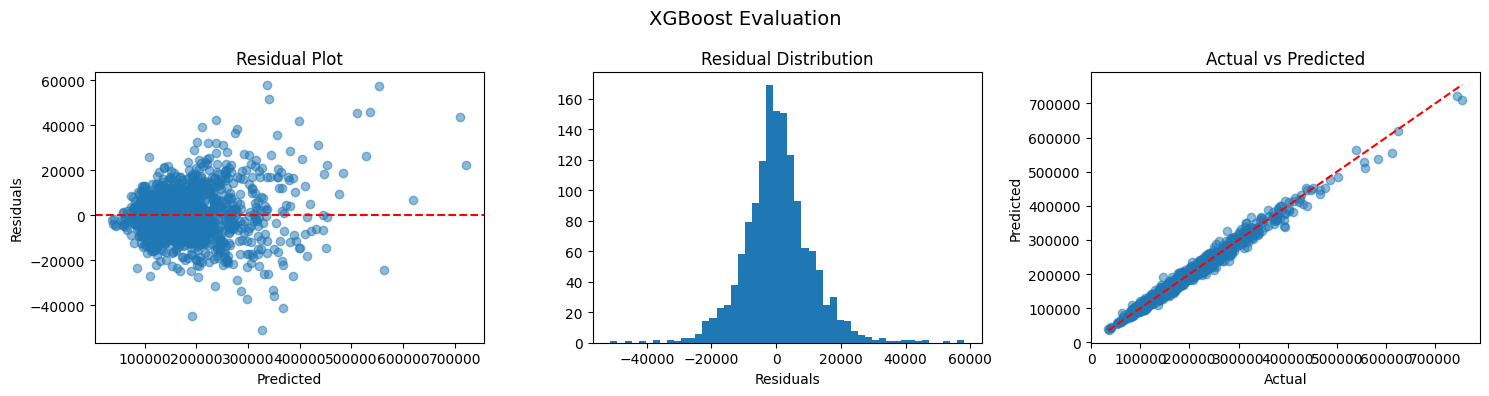

In [30]:
# Evaluate
xgb_results = evaluate_model(xgb_model, train_X_processed, train_y, 
                              model_name="XGBoost", use_log=True)

## Predict with test set

In [31]:
# Predict with test set
test_y_pred = model.predict(test_X_processed)

In [32]:
test_y_pred

array([105421.63365637, 153749.90533836, 165561.98641381, ...,
       145932.17731117, 105033.12721615, 224412.49256947], shape=(1459,))

In [36]:
submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": test_y_pred
})

In [37]:
submission.to_csv("submission.csv", index=False)

In [38]:
submission.shape

(1459, 2)